# Feature Engineering

In this section, we begin by exploring both the tracks and artists datasets, with particular attention to the correlations between the original features.

Based on these insights, we create new features that may enhance the clustering process, which aims to distinguish between different types of rap.

Finally, we review the results of our feature engineering and perform a final outlier removal to ensure the dataset is ready for clustering.

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns

In [59]:
tracks = pd.read_csv("../../prepared_datasets/tracks.csv")
artists = pd.read_csv("../../prepared_datasets/artists.csv")

tracks = tracks.copy()
artists = artists.copy()

print(f"Tracks shape: {tracks.shape[0]} rows x {tracks.shape[1]} columns")
print(f"Artists shape: {artists.shape[0]} rows x {artists.shape[1]} columns\n")

print(f"Tracks sample:\n", tracks.head())
print(f"Artists sample:\n", artists.head())

print(f"Tracks types:", tracks.info())
print(f"Artists types:", artists.info())

Tracks shape: 10677 rows x 25 columns
Artists shape: 88 rows x 4 columns

Tracks sample:
           title    id_artist  swear_IT  swear_EN  n_sentences  n_tokens  \
0  ​polka 2 :-/  ART04205421        13         6        102.0     911.0   
1         POLKA  ART04205421         9        12         56.0     675.0   
2  ​britney ;-)  ART04205421        16        12         88.0     758.0   
3           CEO  ART04205421         8         3         37.0     382.0   
4        LONDRA  ART04205421         1         0         48.0     429.0   

   tokens_per_sent  char_per_tok  lexical_density  avg_token_per_clause  ...  \
0         8.931373      4.170455         0.575284              8.133929  ...   
1        12.053571      4.280851         0.648936             12.500000  ...   
2         8.613636      4.075251         0.556856              8.422222  ...   
3        10.324324      4.023881         0.534328              6.701754  ...   
4         8.937500      3.922857         0.491429          

---

## Correlation Heatmaps for the Original Features

In this section, we compute and visualize three correlation heatmaps for:
1. track-related features;
2. artist-related features;
3. the combined set of features.

The goal of this analysis is to identify meaningful correlations that may suggest the creation of new features, as well as to guide dimensionality reduction by avoiding redundant information (e.g. features exhibiting very high mutual correlation).

This step is particularly important, as clustering algorithms tend to perform poorly when applied to highly correlated features.

In [60]:
def og_tracks_heatmap(tracks):
    numeric_cols = tracks.select_dtypes(include=[np.number]).columns

    tracks_for_corr = tracks[numeric_cols]

    og_tracks_corr = tracks_for_corr.corr()

    plt.figure(figsize=(14, 12))
    sns.heatmap(og_tracks_corr, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5, annot_kws={"size": 8})
    plt.title("Heatmap of correlations - original tracks features")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()
    return

def og_artists_heatmap(artists):
    numeric_cols = artists.select_dtypes(include=[np.number]).columns
    artists_for_corr = artists[numeric_cols]

    og_artists_corr = artists_for_corr.corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(og_artists_corr, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5, annot_kws={"size": 8})
    plt.title("Heatmap of correlations - original artists features")
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()
    return

def og_full_heatmap(merged_dataset):
    # Selecting only numeric columns
    numeric_cols = merged_dataset.select_dtypes(include=[np.number]).columns

    og_for_corr = merged_dataset[numeric_cols]

    og_corr = og_for_corr.corr()

    # Print couples of features with high correlation
    print("\nCouples of features with correlation > 0.70:")
    high_corr = []
    for i in range(len(og_corr.columns)):
        for j in range(i):
            corr_value = og_corr.iloc[i, j]
            if abs(corr_value) > 0.70:
                feat1 = og_corr.columns[i]
                feat2 = og_corr.columns[j]
                high_corr.append((feat1, feat2, corr_value))
                print(f"{feat1}, {feat2} = {corr_value:.2f}")

    plt.figure(figsize=(18, 14))
    sns.heatmap(og_corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, linecolor='gray', annot_kws={"size": 8})
    plt.title("Heatmap of correlations - original features")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()
    return 

Original merged dataset shape: 9722 rows x 28 columns
Columns: ['title', 'id_artist', 'swear_IT', 'swear_EN', 'n_sentences', 'n_tokens', 'tokens_per_sent', 'char_per_tok', 'lexical_density', 'avg_token_per_clause', 'bpm', 'centroid', 'rolloff', 'flux', 'rms', 'zcr', 'flatness', 'spectral_complexity', 'pitch', 'loudness', 'disc_number', 'track_number', 'duration_ms', 'popularity', 'album_release_year', 'latitude', 'longitude', 'active_start_year']

 
 



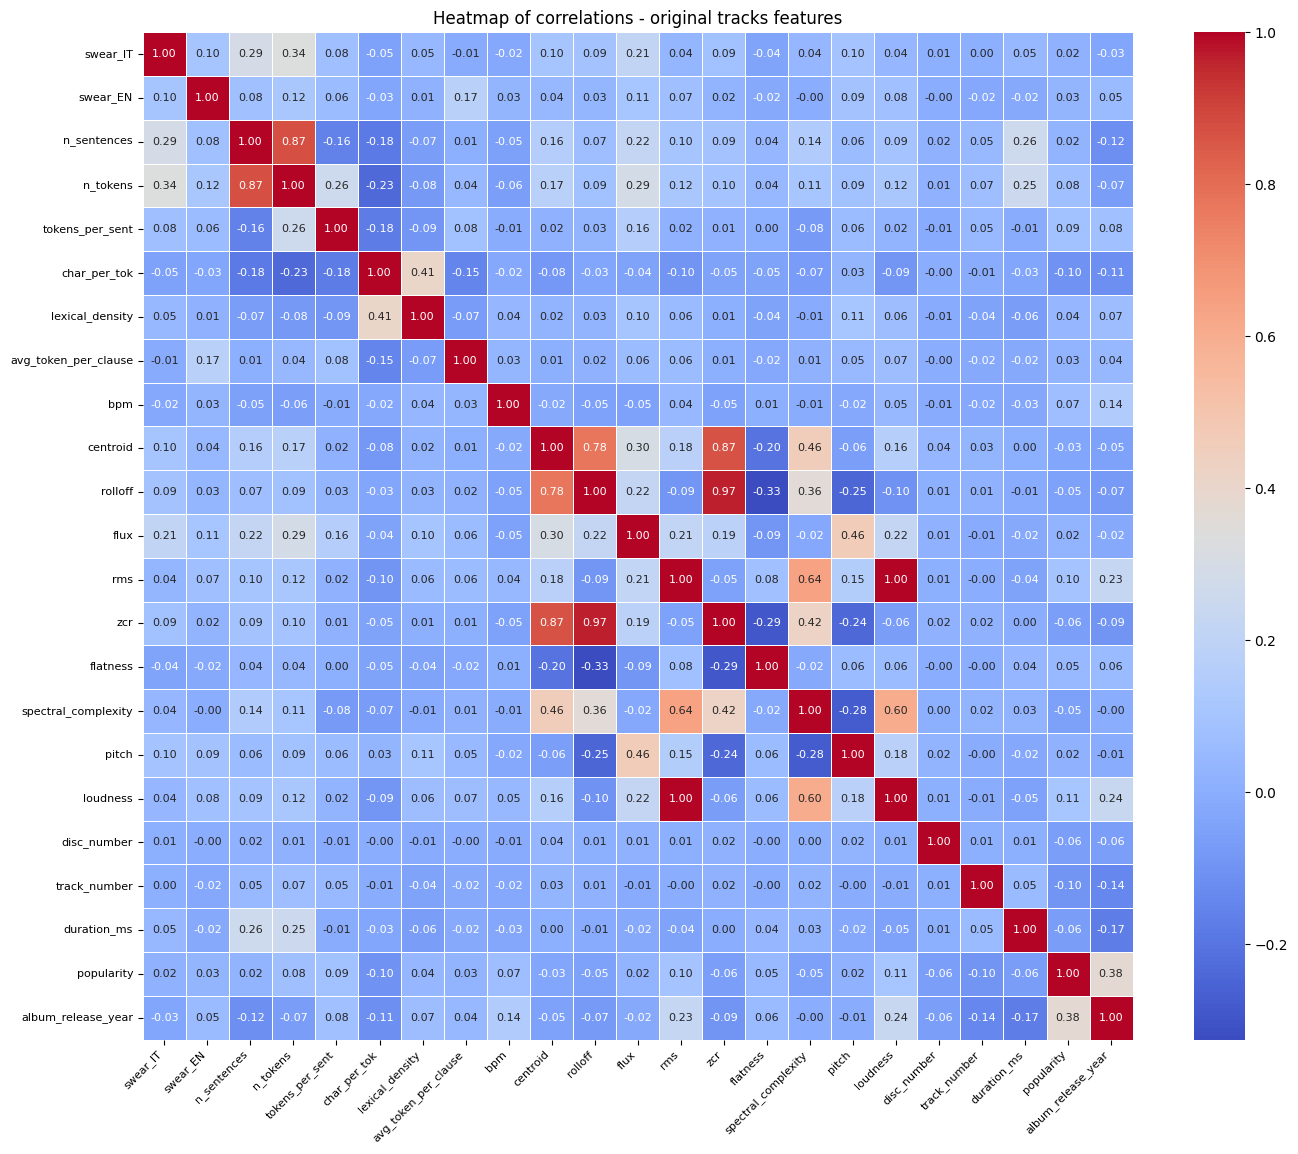

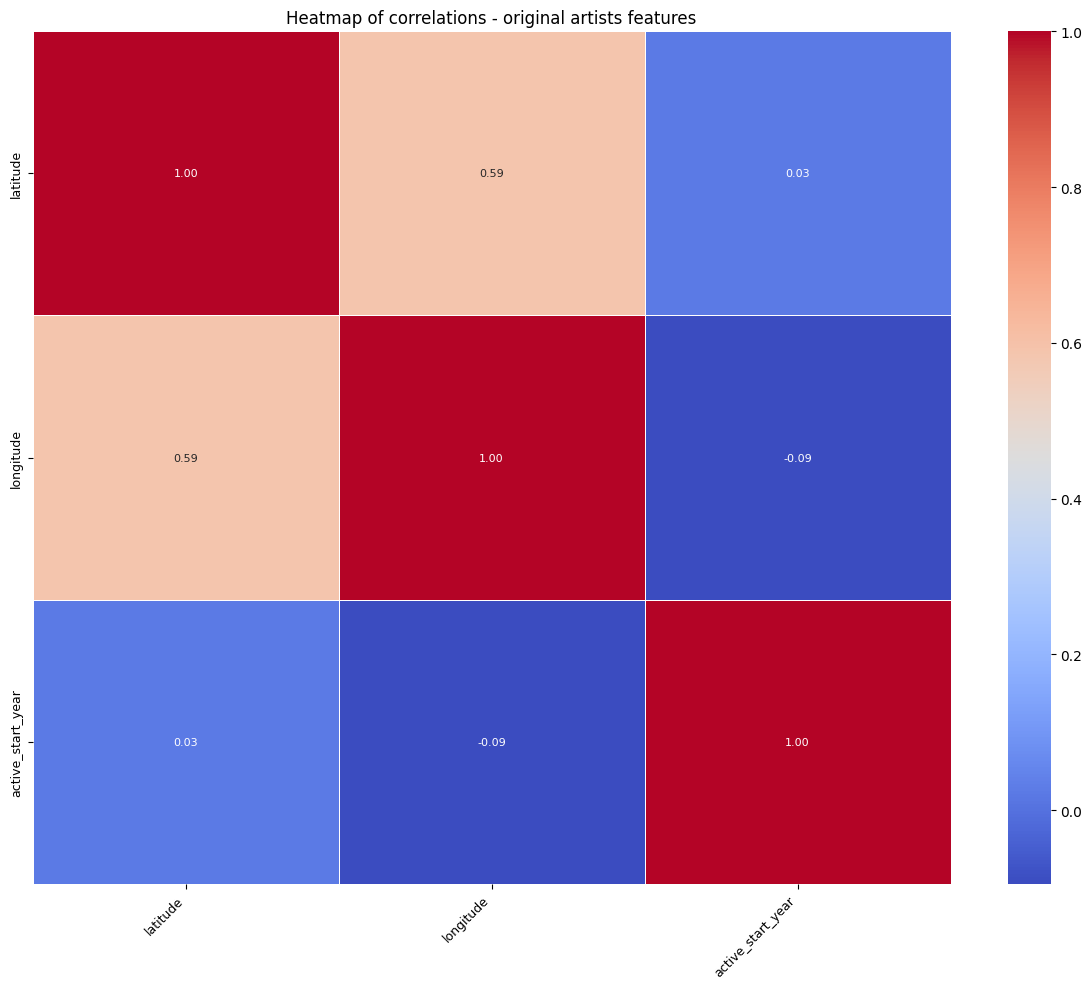


Couples of features with correlation > 0.70:
n_tokens, n_sentences = 0.87
rolloff, centroid = 0.78
zcr, centroid = 0.87
zcr, rolloff = 0.97
loudness, rms = 1.00


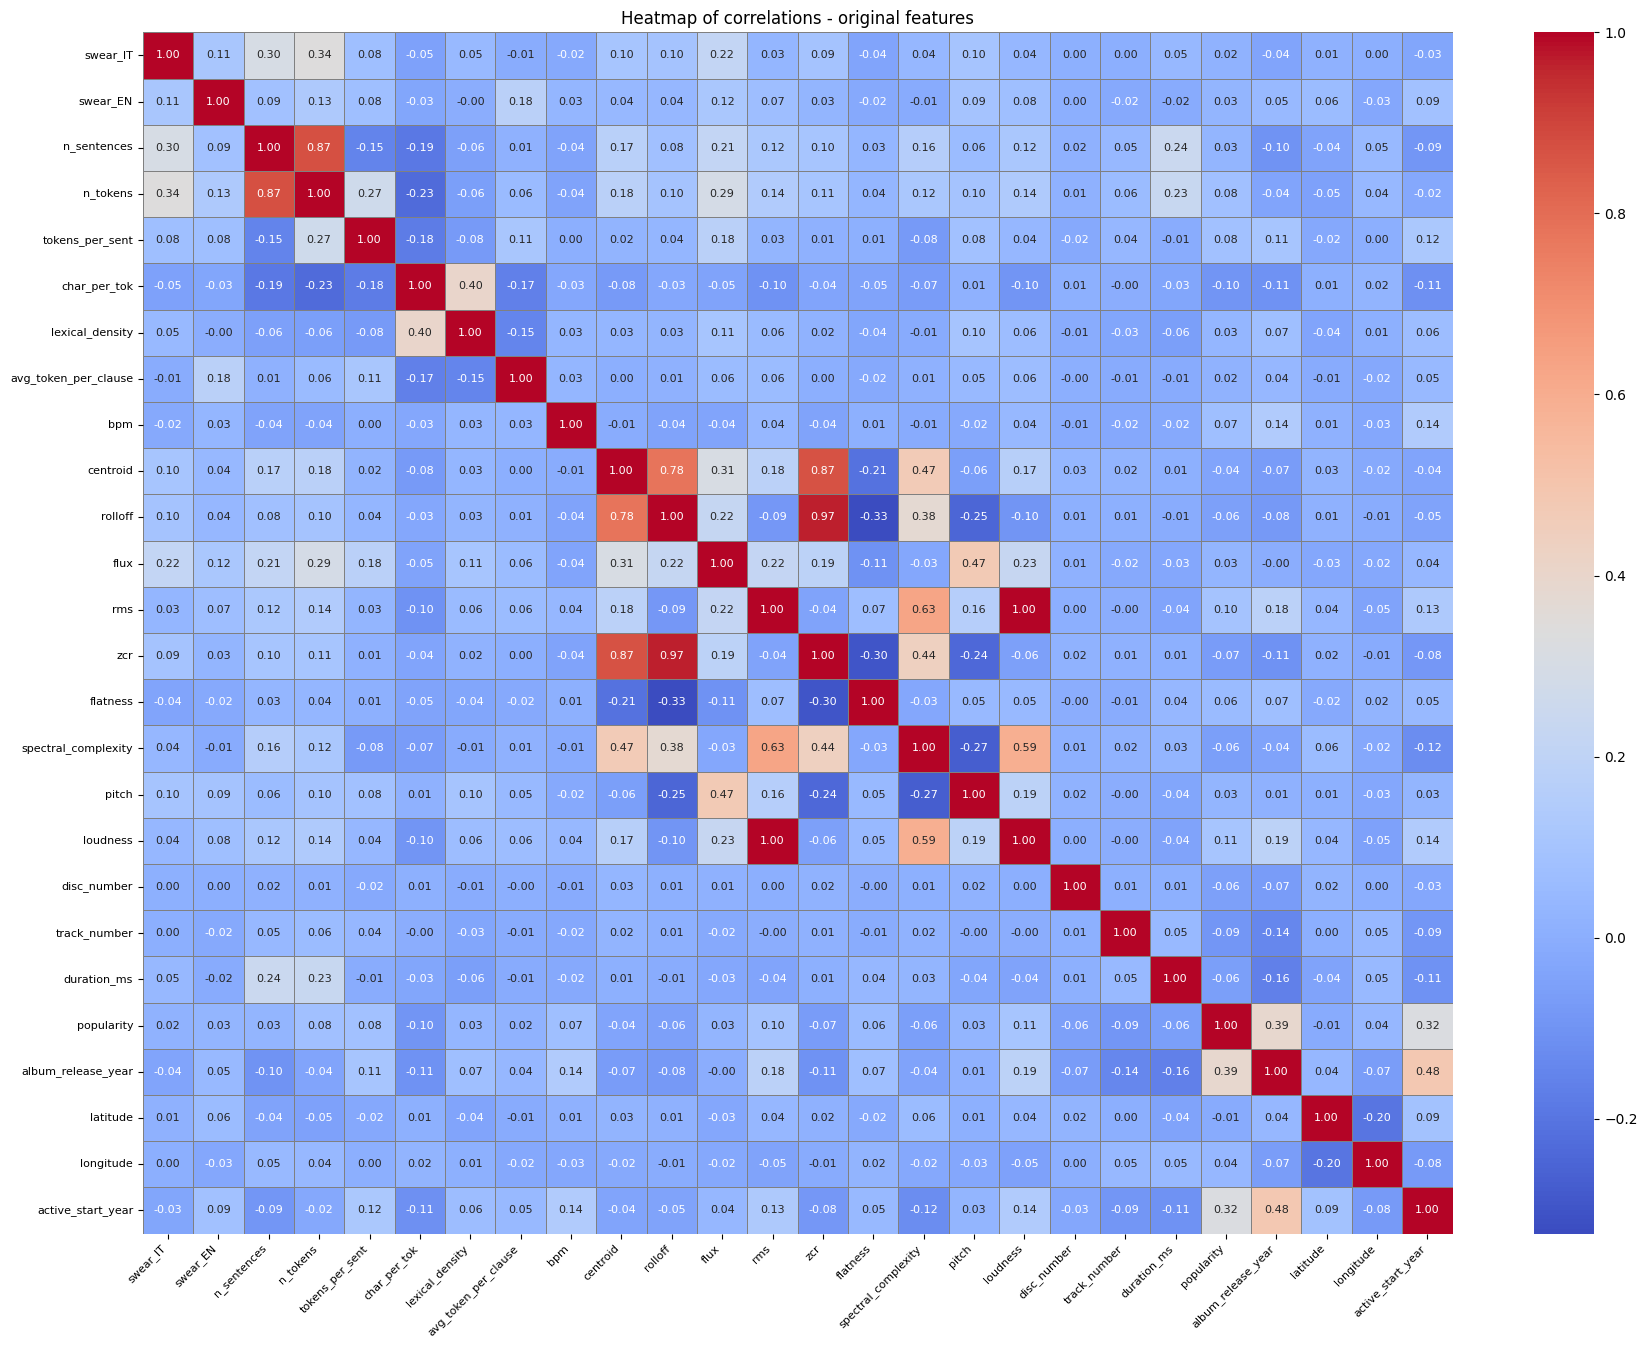

In [61]:
# Merging the two datasets
merged_dataset = tracks.merge(
    artists,
    left_on='id_artist',
    right_on='id_author',
    how='left'
)

if "id_author" in merged_dataset.columns:
    merged_dataset = merged_dataset.drop(columns=["id_author"])

merged_dataset = merged_dataset.dropna()
print(f"Original merged dataset shape: {merged_dataset.shape[0]} rows x {merged_dataset.shape[1]} columns")
print(f"Columns: {merged_dataset.columns.tolist()}")

print("\n \n \n")

# Original heatmaps
og_tracks_heatmap(tracks)

og_artists_heatmap(artists)

og_full_heatmap(merged_dataset)

Following the analysis of the correlation heatmaps, we remove highly correlated features that are not beneficial for feature engineering and subsequent clustering.

In particular, we drop the _loudness_ feature due to its perfect correlation with _rms_ (correlation coefficient = 1.00).  
Similarly, we remove _zcr_ because it shows strong correlations with other audio features, namely:
- _zcr_ and _centroid_ → 0.87;
- _zcr_ and _rolloff_ → 0.97.

Removing these features helps reduce redundancy and mitigates the negative impact of multicollinearity on clustering performance.

In [62]:
# "loudness", "rms" = 1.00
merged_dataset = merged_dataset.drop(columns=["loudness"])

# "zcr" high corr w/ "rolloff"(0.97), "centroid"(0.87)
merged_dataset = merged_dataset.drop(columns=["zcr"])

---

## Feature Engineering

Given that the clustering objective is to identify different styles of Italian rap, we construct both lexical and stylistic features derived from the original variables.

The mathematical logic underlying feature construction is as follows:
- when the original features share the same unit of measurement, they are combined through summation;
- when the original features have different units of measurement, they are combined through multiplication.

The logic behind these mathematical choices is discussed in greater detail in the project documentation.

In [63]:
"""
    LEXICAL FEATURES
"""
def swear_ratio(merged_dataset):
    df = merged_dataset.copy()

    df["swear_ratio"] = (df["swear_IT"] + df["swear_EN"])/df["n_tokens"]
    return df

def syntactic_complexity(merged_dataset):
    df = merged_dataset.copy()

    df["syntactic_complexity"] = df["n_tokens"] * df["char_per_tok"] * df["lexical_density"]
    return df

def flow_complexity(merged_dataset):
    df = merged_dataset.copy()

    df["flow_complexity"] = df["tokens_per_sent"] * df["flux"]
    return df



"""
    SOUND AND STYLE FEATURES
"""
def percussiveness(merged_dataset):
    df = merged_dataset.copy()

    df["percussiveness"] = df["rolloff"] * df["flux"] * df["rms"]
    return df

def timbre_brightness(merged_dataset):
    df = merged_dataset.copy()

    df["timbre_brightness"] = df["centroid"] + df["rolloff"] / 2
    return df

def harmonic_richness(merged_dataset):
    df = merged_dataset.copy()

    tonality = 1 - df["flatness"]

    df["harmonic_richness"] = tonality * df["spectral_complexity"] * df["pitch"]
    return df

def trap_index(merged_dataset):
    df = merged_dataset.copy()

    """
        Identifies trap characteristics:
        - bpm -> 130-170 (or 65-85 half-time)
        - Sub-bass (low rolloff)
        - high rms
    """
    # bpm score
    bpm_trap = np.where(
        ((df["bpm"] >= 130) & (df["bpm"] <= 170)) | 
        ((df["bpm"] >= 65) & (df["bpm"] <= 85)),
        1.0, 0.3
    )
    
    subbass_score = df["timbre_brightness"].max() - df["timbre_brightness"]
    
    df["trap_index"] = bpm_trap * subbass_score * df["rms"]
    return df

def boombap_index(merged_dataset):
    df = merged_dataset.copy()

    """
        Identifies boom-bap/old school:
        - bpm -> 85-95
        - emphasizes mid range
    """
    # bpm score
    bpm_bb = np.where((df["bpm"] >= 85) & (df["bpm"] <= 95), 1.0, 0.3)
    
    spectral_mid = df["spectral_complexity"].max() -\
        np.abs(df["spectral_complexity"] - (df["spectral_complexity"]/2)) * 2
    
    df["boombap_index"] = bpm_bb * spectral_mid
    return df

def cloud_rap_index(merged_dataset):
    df = merged_dataset.copy()

    """
        Identifies cloud rap:
        - bpm -> 60-80
        - low flatness (harmonic)
        - low flux (sound changing slowly) 
    """
    # bpm score
    bpm_cloud = np.where((df["bpm"] >= 60) & (df["bpm"] <= 80), 1.0, 0.3)
    
    flatness_low = df["flatness"].max() - df["flatness"]

    flux_low = df["flux"].max() - df["flux"]
    
    df["cloud_rap_index"] = bpm_cloud * flatness_low * flux_low
    return df

def drill_index(merged_dataset):
    df = merged_dataset.copy()

    """
    Identifies UK Drill style:
    - bpm -> 135-150
    - low rolloff (dark sound)
    - Sliding bass
    """
    # BPM drill
    bpm_drill = np.where((df["bpm"] >= 135) & (df["bpm"] <= 150), 1.0, 0.3)

    subbass_score = df["timbre_brightness"].max() - df["timbre_brightness"]

    df["drill_index"] = bpm_drill * subbass_score * df["pitch"] * df["flatness"]
    return df

---

## Merged Dataset Analysis

We begin by examining the shape of the newly merged dataset and by plotting its correlation matrix.

Based on the observed pairwise correlations between features, we identify and remove those that are deemed redundant or uninformative for clustering.

Notably, we also drop the _timbre_brightness_ feature, which was created during the feature engineering phase, as it is subsequently reused in the construction of other features.

In [64]:
def full_heatmap(final_merged_dataset):
    # Selecting only numeric columns
    numeric_cols = final_merged_dataset.select_dtypes(include=[np.number]).columns

    final_for_corr = final_merged_dataset[numeric_cols]
    
    enriched_full_corr = final_for_corr.corr()
    
    # Print couples of features with high correlation
    print("\nCouples of features with correlation > 0.70")
    high_corr = []
    for i in range(len(enriched_full_corr.columns)):
        for j in range(i):
            corr_value = enriched_full_corr.iloc[i, j]
            if abs(corr_value) > 0.70:
                feat1 = enriched_full_corr.columns[i]
                feat2 = enriched_full_corr.columns[j]
                high_corr.append((feat1, feat2, corr_value))
                print(f"{feat1}, {feat2} = {corr_value:.2f}")
    
    print(f"\nTotal couples with correlation > 0.70: {len(high_corr)}")

    plt.figure(figsize=(18, 14))
    sns.heatmap(enriched_full_corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, linecolor='gray', annot_kws={"size": 8})
    plt.title("Heatmap of correlations - enriched features")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()
    return

Merged dataset shape: 9722 rows x 36 columns
Columns: ['title', 'id_artist', 'swear_IT', 'swear_EN', 'n_sentences', 'n_tokens', 'tokens_per_sent', 'char_per_tok', 'lexical_density', 'avg_token_per_clause', 'bpm', 'centroid', 'rolloff', 'flux', 'rms', 'flatness', 'spectral_complexity', 'pitch', 'disc_number', 'track_number', 'duration_ms', 'popularity', 'album_release_year', 'latitude', 'longitude', 'active_start_year', 'swear_ratio', 'syntactic_complexity', 'flow_complexity', 'percussiveness', 'timbre_brightness', 'harmonic_richness', 'trap_index', 'boombap_index', 'cloud_rap_index', 'drill_index']

Couples of features with correlation > 0.70
n_tokens, n_sentences = 0.87
rolloff, centroid = 0.78
swear_ratio, swear_IT = 0.73
syntactic_complexity, n_sentences = 0.84
syntactic_complexity, n_tokens = 0.95
flow_complexity, tokens_per_sent = 0.92
percussiveness, centroid = 0.72
percussiveness, rolloff = 0.72
timbre_brightness, centroid = 0.78
timbre_brightness, rolloff = 1.00
timbre_brightne

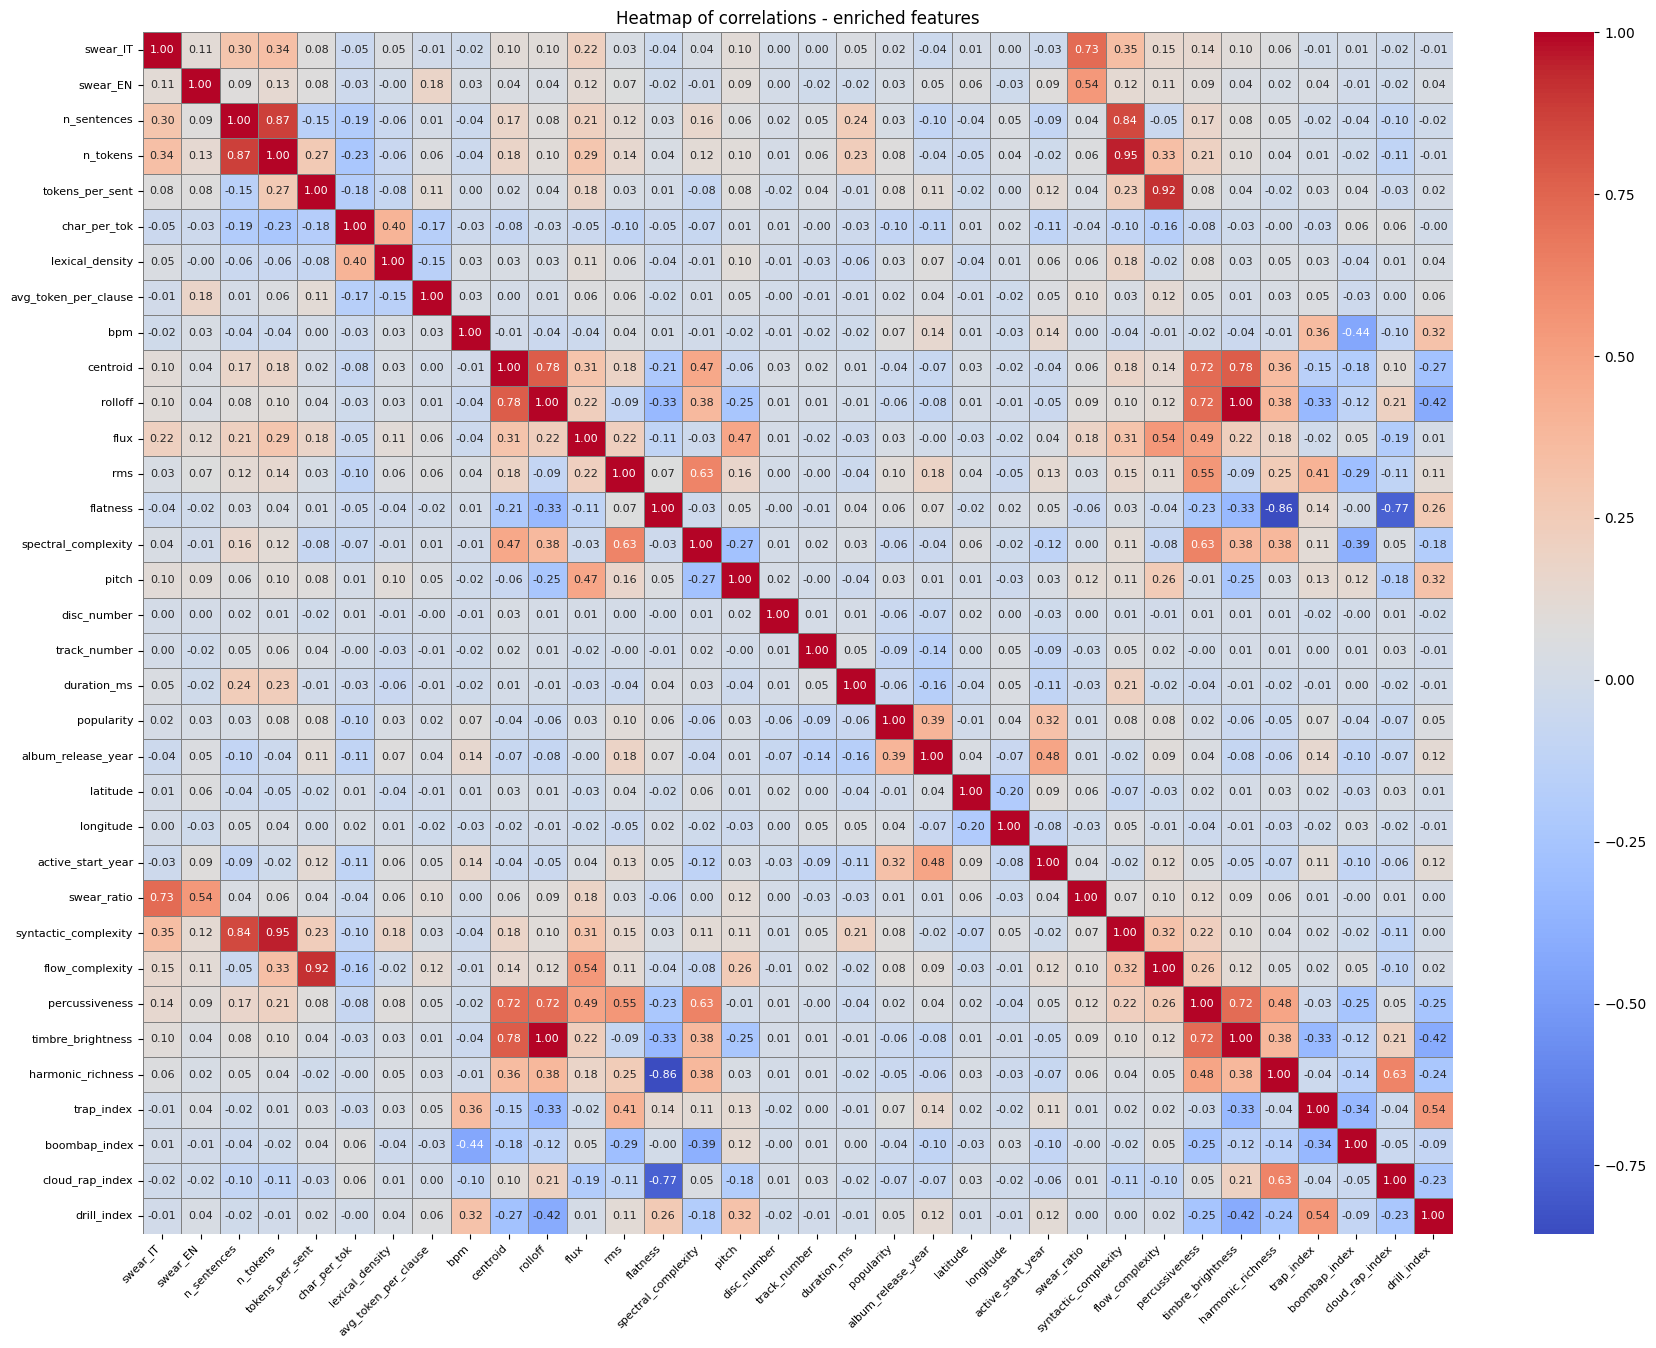

In [65]:
# Tracks features
merged_dataset = swear_ratio(merged_dataset)
merged_dataset = syntactic_complexity(merged_dataset)
merged_dataset = flow_complexity(merged_dataset)
merged_dataset = percussiveness(merged_dataset)
merged_dataset = timbre_brightness(merged_dataset)
merged_dataset = harmonic_richness(merged_dataset)
merged_dataset = trap_index(merged_dataset)
merged_dataset = boombap_index(merged_dataset)
merged_dataset = cloud_rap_index(merged_dataset)
merged_dataset = drill_index(merged_dataset)
    
print(f"Merged dataset shape: {merged_dataset.shape[0]} rows x {merged_dataset.shape[1]} columns")
print(f"Columns: {merged_dataset.columns.tolist()}")

# Enriched dataset
full_heatmap(merged_dataset)

In [66]:
# Removing redundant columns
merged_dataset = merged_dataset.drop(columns=[
    "id_artist",
    "title",
    "swear_IT",
    "swear_EN",
    "n_sentences",
    "n_tokens",
    "tokens_per_sent",
    "char_per_tok",
    "lexical_density",
    "bpm",
    "centroid",
    "rolloff",
    "flux",
    "rms",
    "flatness",
    "spectral_complexity",
    "pitch",
    "disc_number",
    "track_number",
    "album_release_year",
    "latitude",
    "longitude",
    "active_start_year",
    "timbre_brightness"
    ])   

In [67]:
merged_dataset.to_csv('../../clustering_dataset/merged_dataset.csv', index=False)

---
---

# Data Understanding and Preparation over the Merged Dataset

We begin by performing an exploratory analysis of the merged dataset to gain an overall understanding of its structure and characteristics. In particular, we inspect:

- feature distributions;
- boxplots, in order to identify potential outliers;
- a correlation heatmap to analyze relationships between features.

In [68]:
df = merged_dataset.copy()
df = df.copy()

print(f"Merged dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Merged dataset sample:\n", df.head())
print(f"Merged dataset columns: {df.columns.tolist()}")

Merged dataset shape: 9722 rows x 12 columns
Merged dataset sample:
    avg_token_per_clause  duration_ms  popularity  swear_ratio  \
0              8.133929     207761.0          46     0.020856   
1             12.500000     207761.0          46     0.031111   
2              8.422222     193544.0          39     0.036939   
3              6.701754     169000.0          47     0.028796   
4              8.411765     194779.0          41     0.002331   

   syntactic_complexity  flow_complexity  percussiveness  harmonic_richness  \
0           2185.667694        12.949597      749.867573       10685.779648   
1           1875.149389        16.312098      923.558260       17961.470393   
2           1720.151111        11.905768      718.697137       14462.555735   
3            821.328082        16.001670      353.256499        5273.616923   
4            827.027951         9.729363      436.723786        8243.404892   

   trap_index  boombap_index  cloud_rap_index   drill_index  
0  

In [69]:
def data_distribution(df):
    num_cols = len(df.columns)
    cols = df.columns

    # Grid size: square-ish layout
    n_rows = math.ceil(num_cols / 2)
    n_cols = 2 if num_cols > 1 else 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))

    # Flatten axes array even if there's only 1 plot
    axes = axes.flatten() if num_cols > 1 else [axes]

    for ax, col in zip(axes, cols):
        ax.hist(df[col], bins=30, edgecolor='black', alpha=0.7)
        ax.set_title(f'Distribuzione {col}')
        ax.set_xlabel('Valore')
        ax.set_ylabel('Frequenza')

    # Hide unused subplots if any
    for ax in axes[num_cols:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()
    return

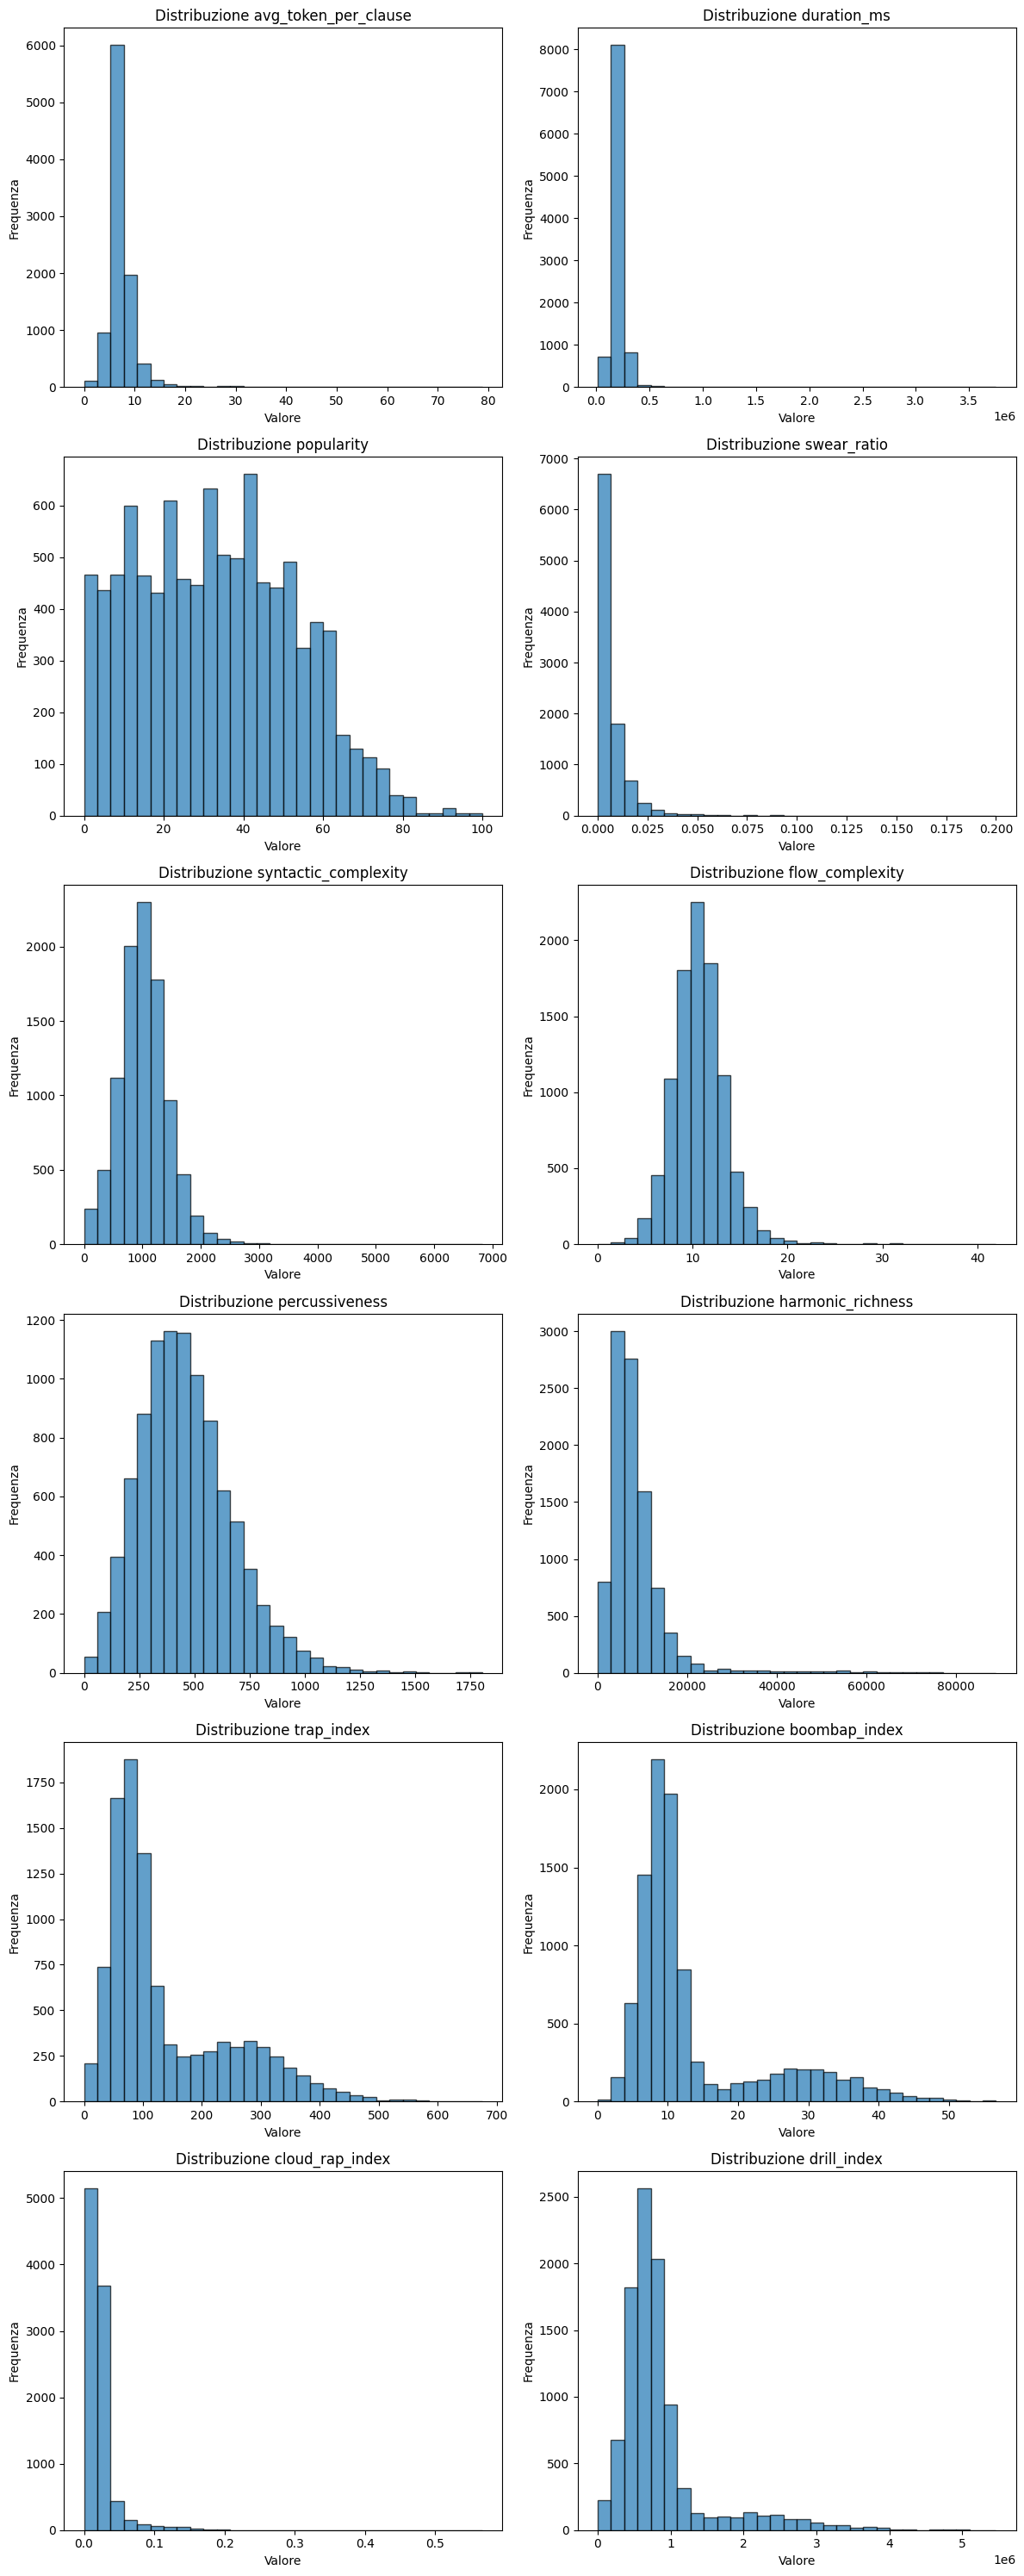

In [70]:
data_distribution(df)

In [71]:
def boxplots(df):
    num_cols = len(df.columns)
    cols = df.columns

    # Grid size: square-ish layout
    n_rows = math.ceil(num_cols / 2)
    n_cols = 2 if num_cols > 1 else 1
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))

    # Flatten axes array to simplify iteration
    axes = axes.flatten() if num_cols > 1 else [axes]

    for ax, col in zip(axes, cols):
        ax.boxplot(df[col].dropna(), vert=True)
        ax.set_title(f'Boxplot {col}')
        ax.set_ylabel('Valore')

    # Hide unused axes (if grid > num columns)
    for ax in axes[num_cols:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()
    return

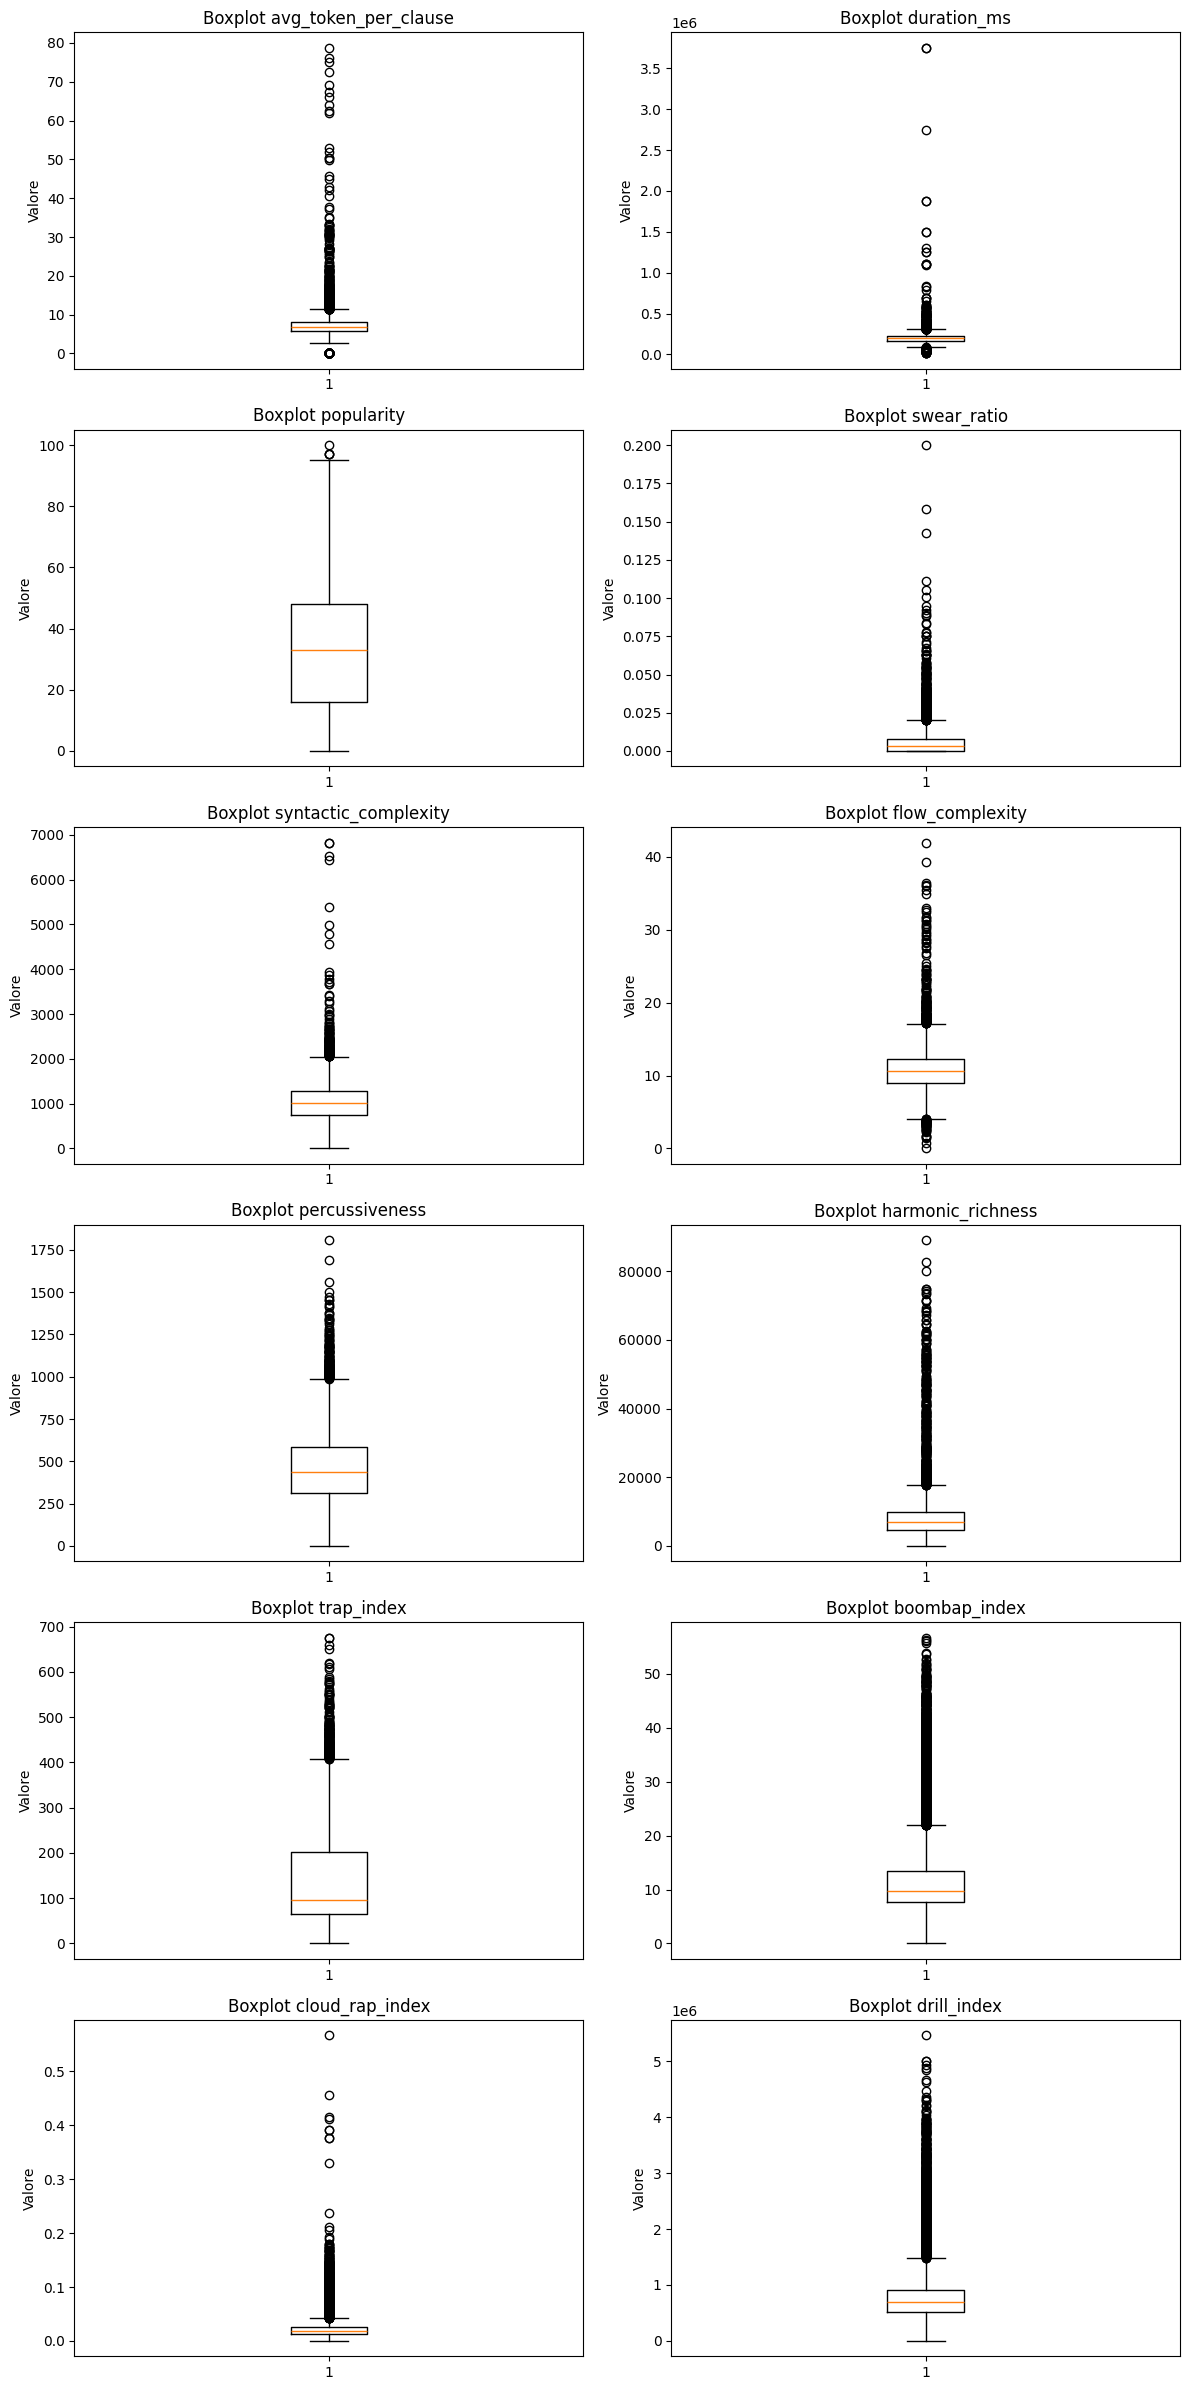

In [72]:
boxplots(df)

In [73]:
def full_heatmap(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    corr = df[numeric_cols].corr()

    plt.figure(figsize=(18, 14))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, linecolor='gray', annot_kws={"size": 8})
    plt.title("Heatmap of correlations")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()
    return

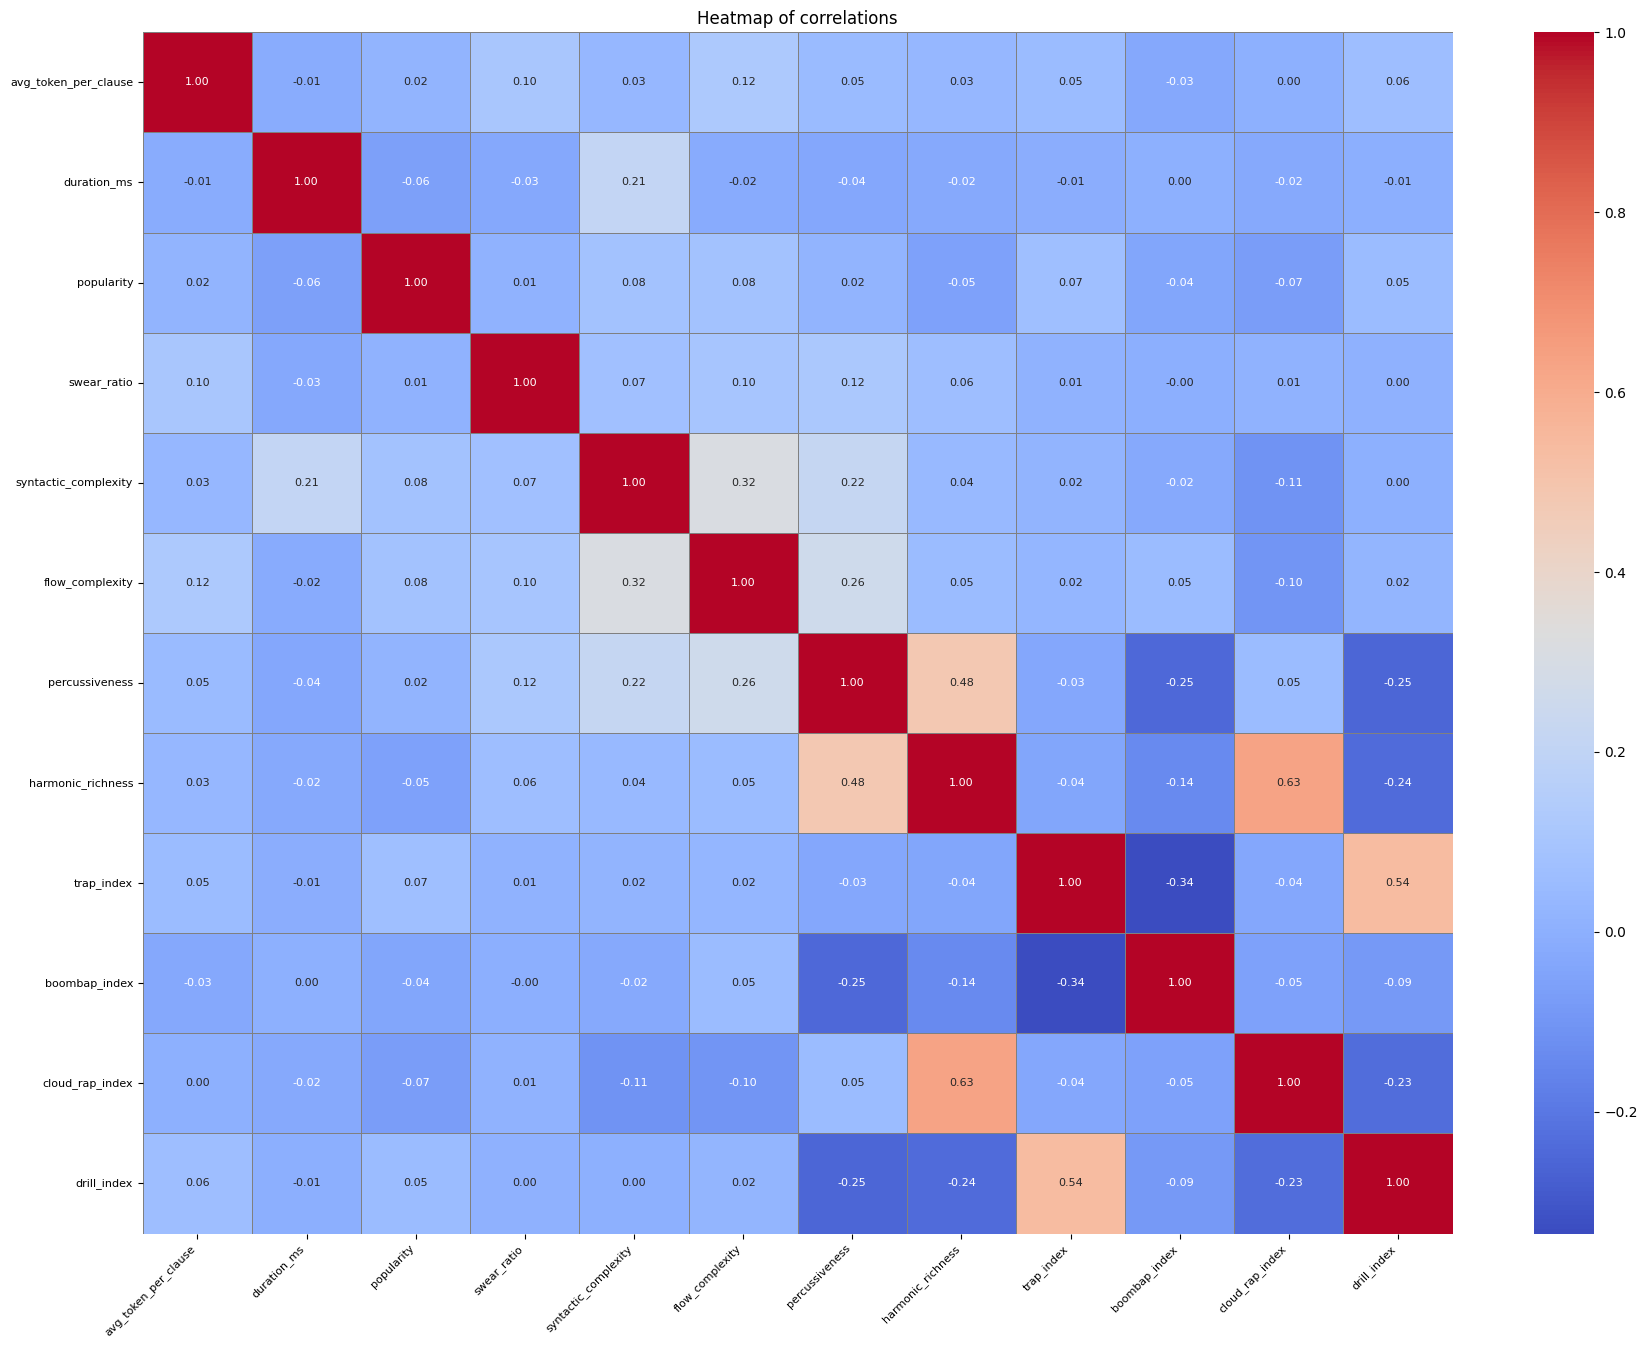

In [74]:
full_heatmap(df)

---

## Outlier Removal

As indicated by the boxplot visualizations, several features exhibit a substantial number of outliers. To address this issue, we remove outliers using the Interquartile Range (IQR) method.

This choice is motivated by the need to reduce the influence of extreme values and to improve the effectiveness of the subsequent clustering phase, with the goal of obtaining more compact and well-separated clusters.

In [75]:
cols = df.columns
cols_no_removal = ["popularity"]

# initialize total outlier mask
outlier_mask_total = pd.Series(False, index=df.index)

for feature in cols:
    col = df[feature]

    min_val = col.min()
    max_val = col.max()
    mu = col.mean()
    sigma = col.std()
    median = col.median()

    print("=" * 40)
    print(f"Feature: {feature}")
    print(f"Min value: {min_val}")
    print(f"Max value: {max_val}")
    print(f"Mean value: {mu}")
    print(f"Standard deviation: {sigma}")
    print(f"Median value: {median}")

    if feature in cols_no_removal:
        print("Skipping feature (no outlier removal)")
        continue

    # IQR-based thresholds
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_mask = (col < lower) | (col > upper)
    n_outliers = outlier_mask.sum()

    print(f"IQR: {IQR}")
    print(f"Acceptable domain (IQR x 1.5): [{lower:.3f}, {upper:.3f}]")
    print(f"Outliers found: {n_outliers}")

    # accumulate total outlier rows
    outlier_mask_total |= outlier_mask

# Counts total of outliers
print("Outlier rows:", outlier_mask_total.sum())

# Removing outlier rows
df_cleaned = df[~outlier_mask_total]

print("\n")
print(
    f"Tracks shape after sound outliers removal: "
    f"{df_cleaned.shape[0]} rows x {df_cleaned.shape[1]} columns"
)
print("\n")

Feature: avg_token_per_clause
Min value: 0.0
Max value: 78.8
Mean value: 7.36620642743708
Standard deviation: 3.595685567996623
Median value: 6.754744002864303
IQR: 2.194923204267452
Acceptable domain (IQR x 1.5): [2.563, 11.342]
Outliers found: 586
Feature: duration_ms
Min value: 11426.0
Max value: 3753057.0
Mean value: 202190.72608516767
Standard deviation: 88606.10510858543
Median value: 195605.5
IQR: 55919.75
Acceptable domain (IQR x 1.5): [85799.875, 309478.875]
Outliers found: 418
Feature: popularity
Min value: 0
Max value: 100
Mean value: 33.00894877597202
Standard deviation: 19.667366110618136
Median value: 33.0
Skipping feature (no outlier removal)
Feature: swear_ratio
Min value: 0.0
Max value: 0.2
Mean value: 0.005942778207859667
Standard deviation: 0.008890831269985373
Median value: 0.003289473684210526
IQR: 0.008161600692479277
Acceptable domain (IQR x 1.5): [-0.012, 0.020]
Outliers found: 500
Feature: syntactic_complexity
Min value: 0.0
Max value: 6824.830771117943
Mean va

---

## Analysis of the Clean Dataset

After the outlier removal phase, we once again analyze the dataset by inspecting feature distributions, boxplots, and the correlation heatmap in order to assess the characteristics of the cleaned data.

Finally, we save the resulting clean dataset, which will be used as input for the clustering analysis.

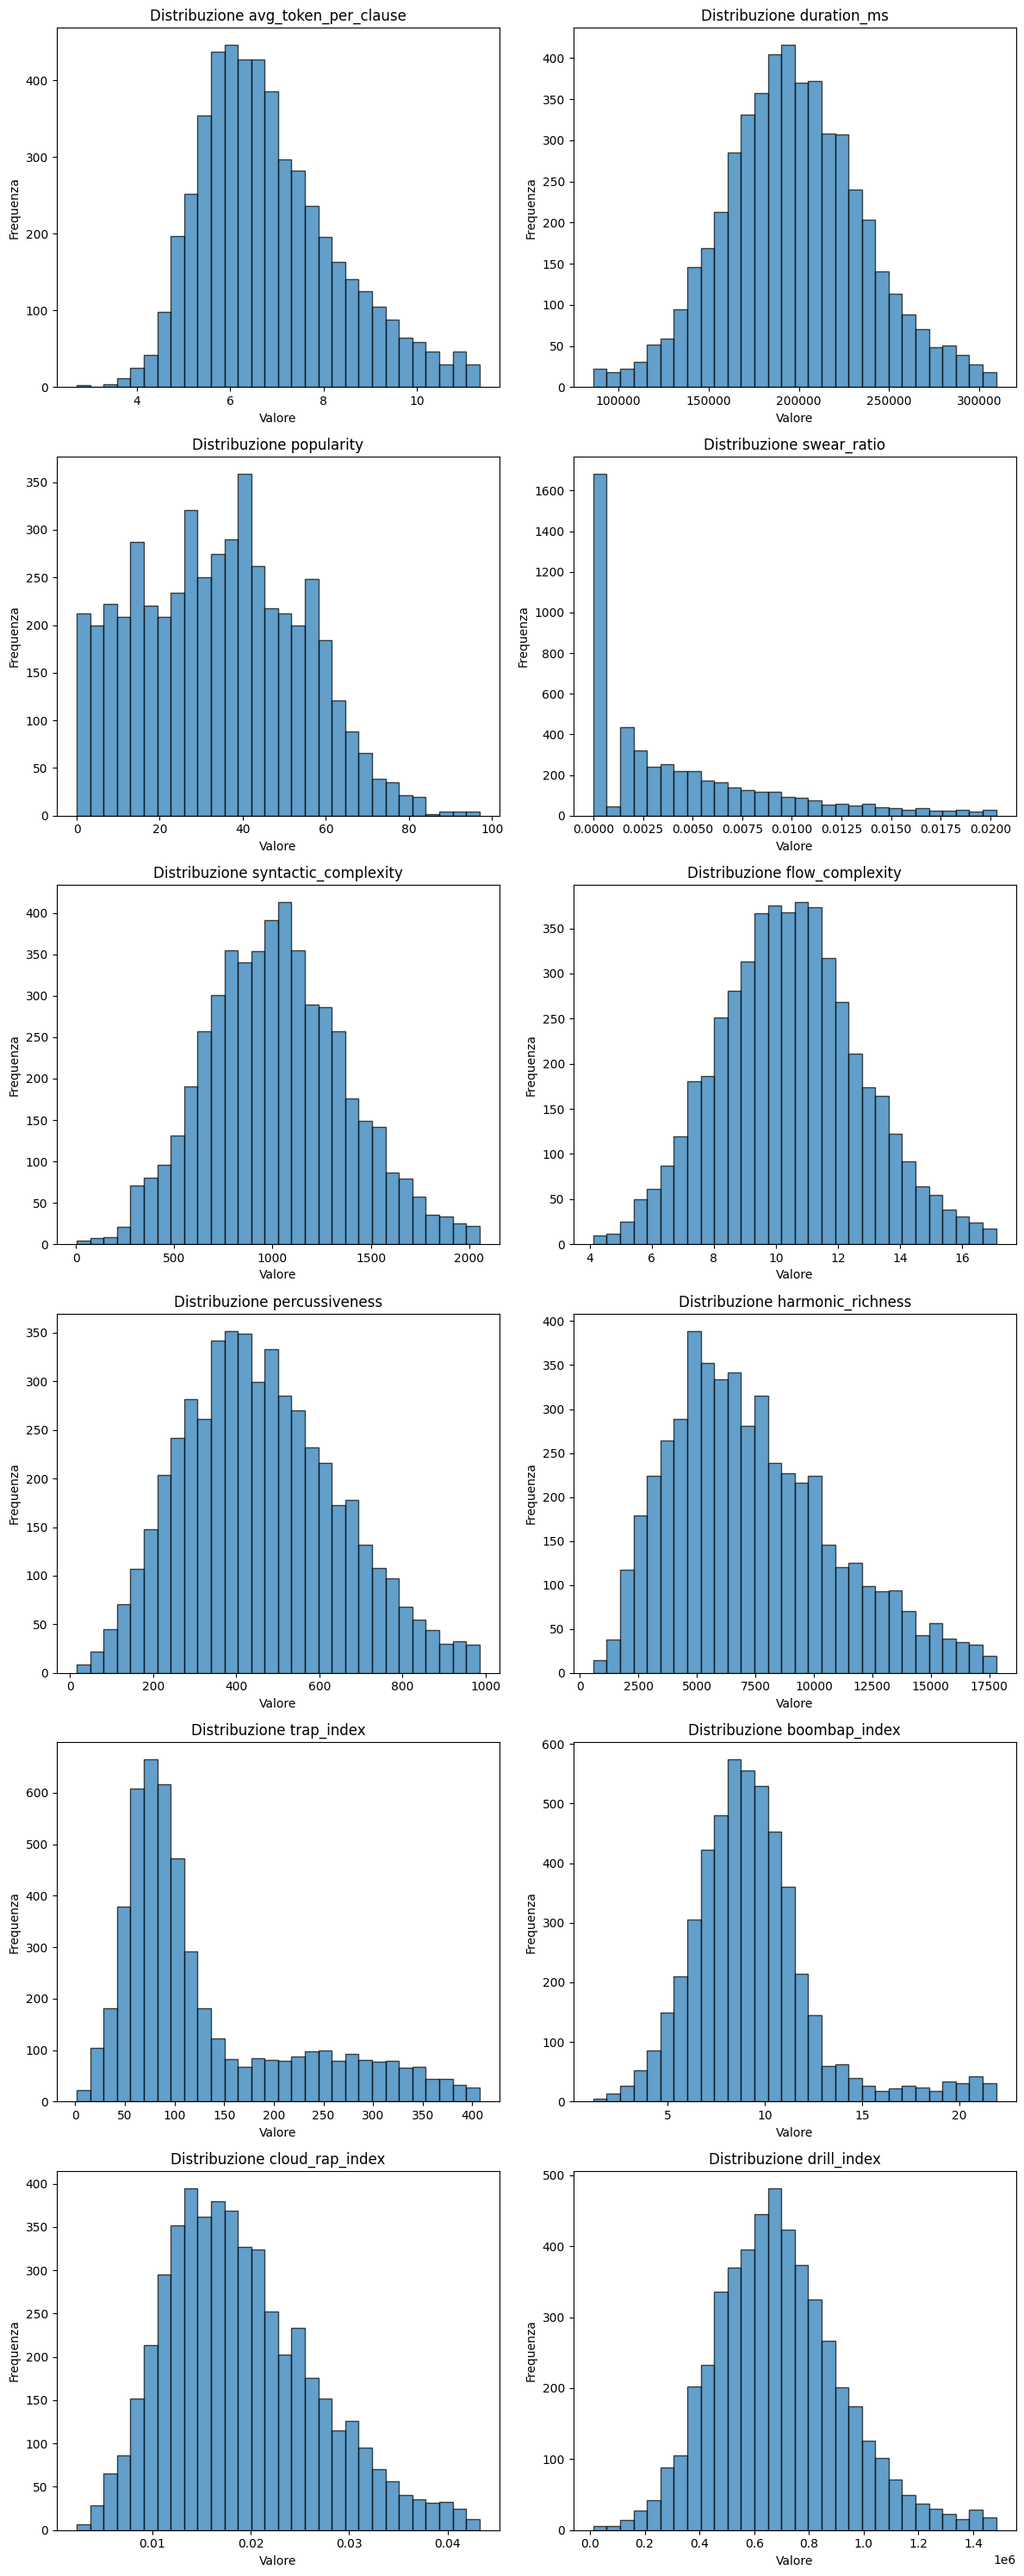

In [76]:
data_distribution(df_cleaned)

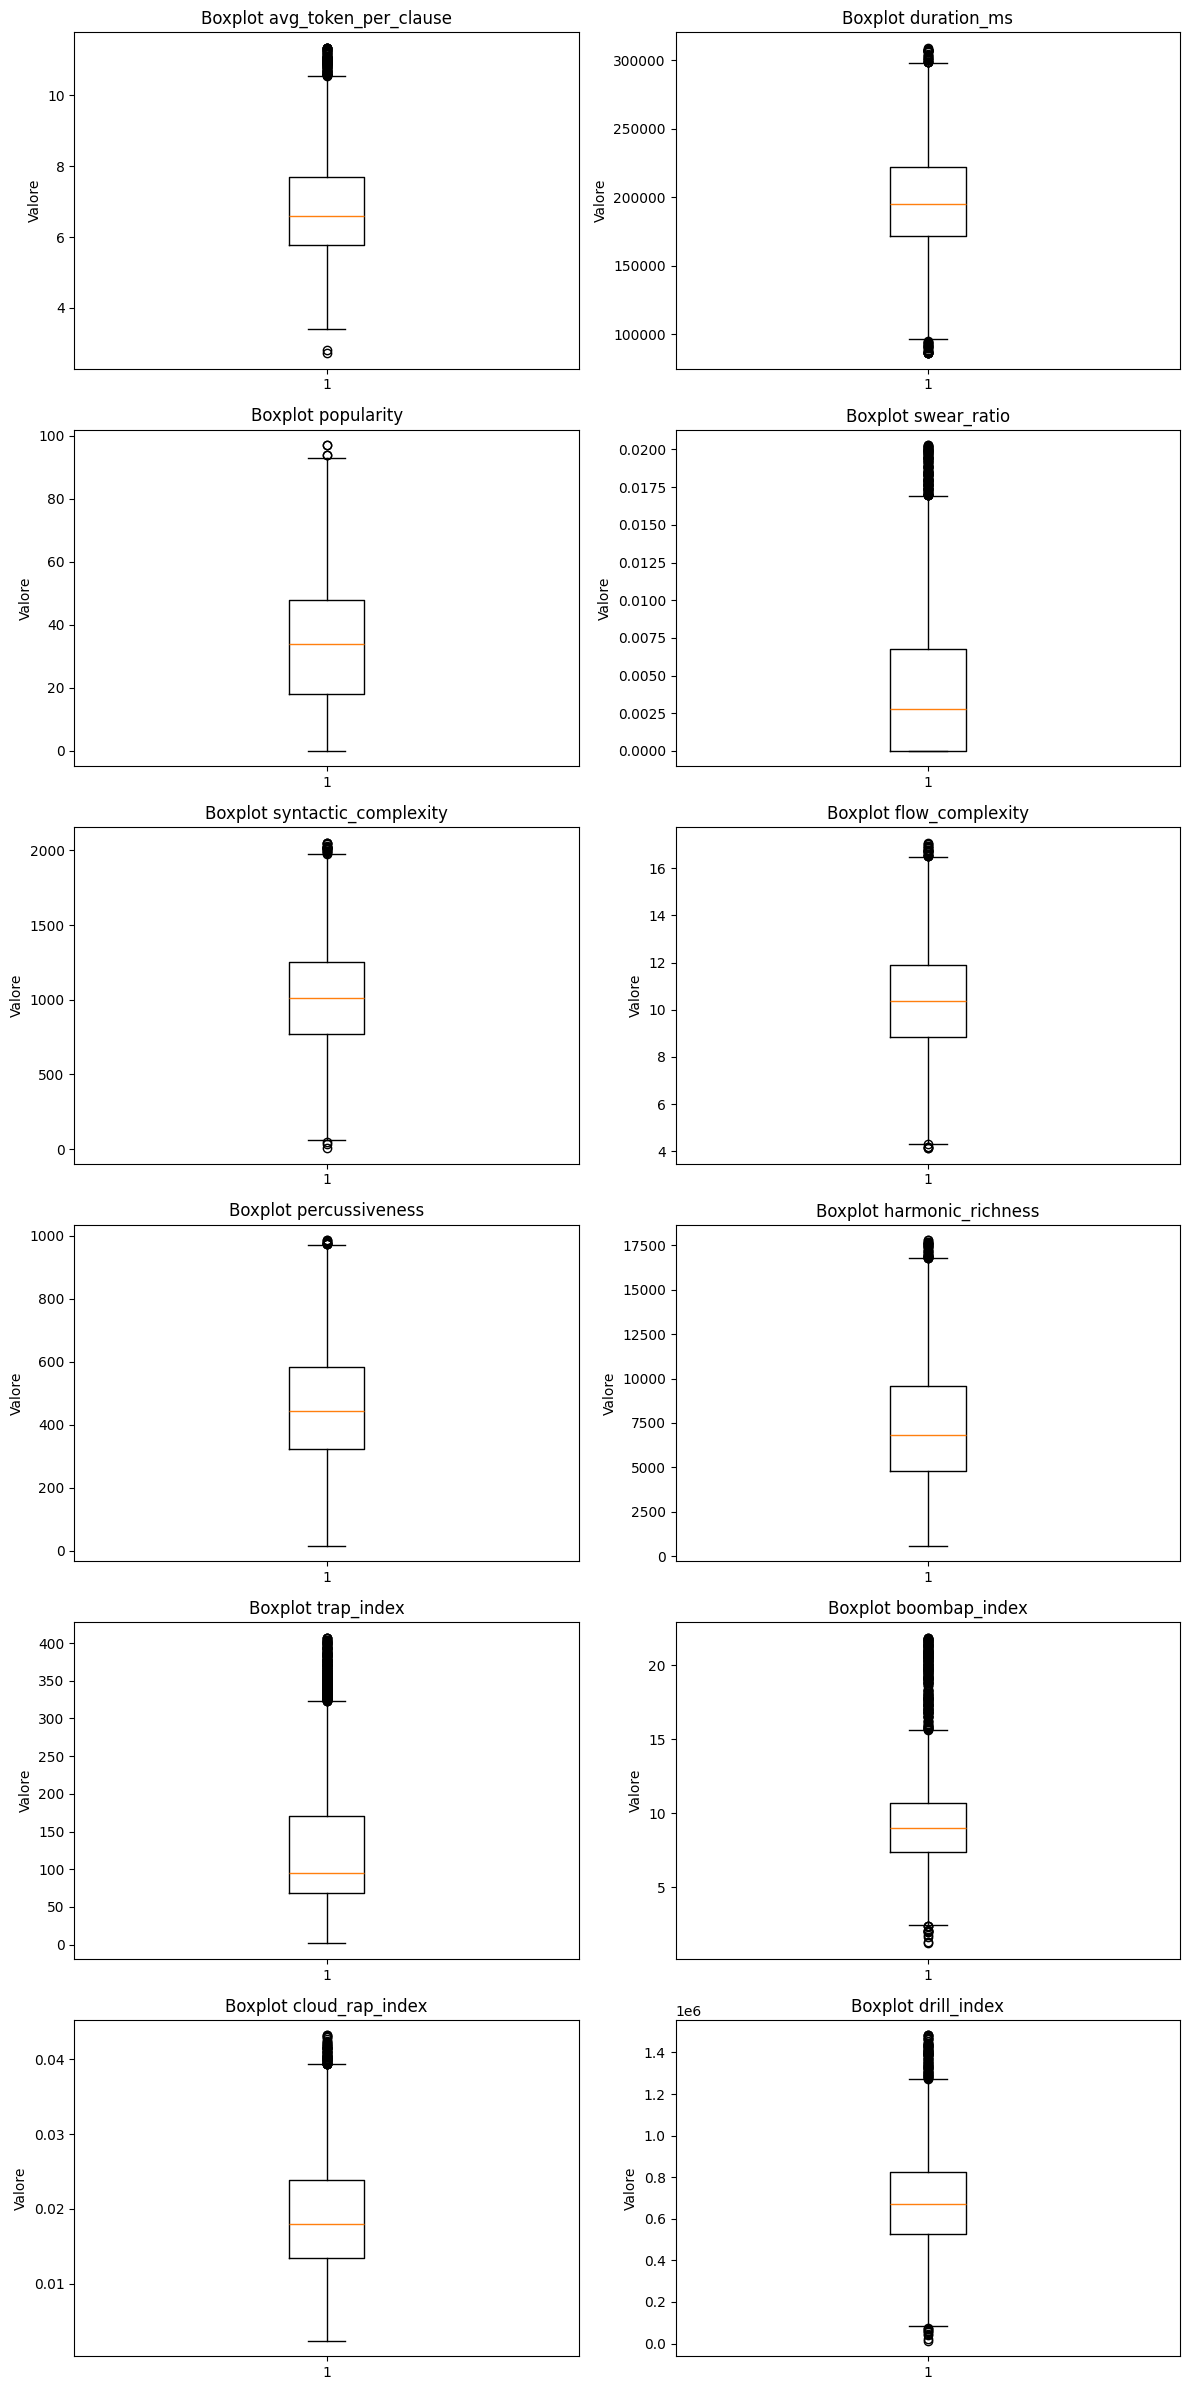

In [77]:
boxplots(df_cleaned)

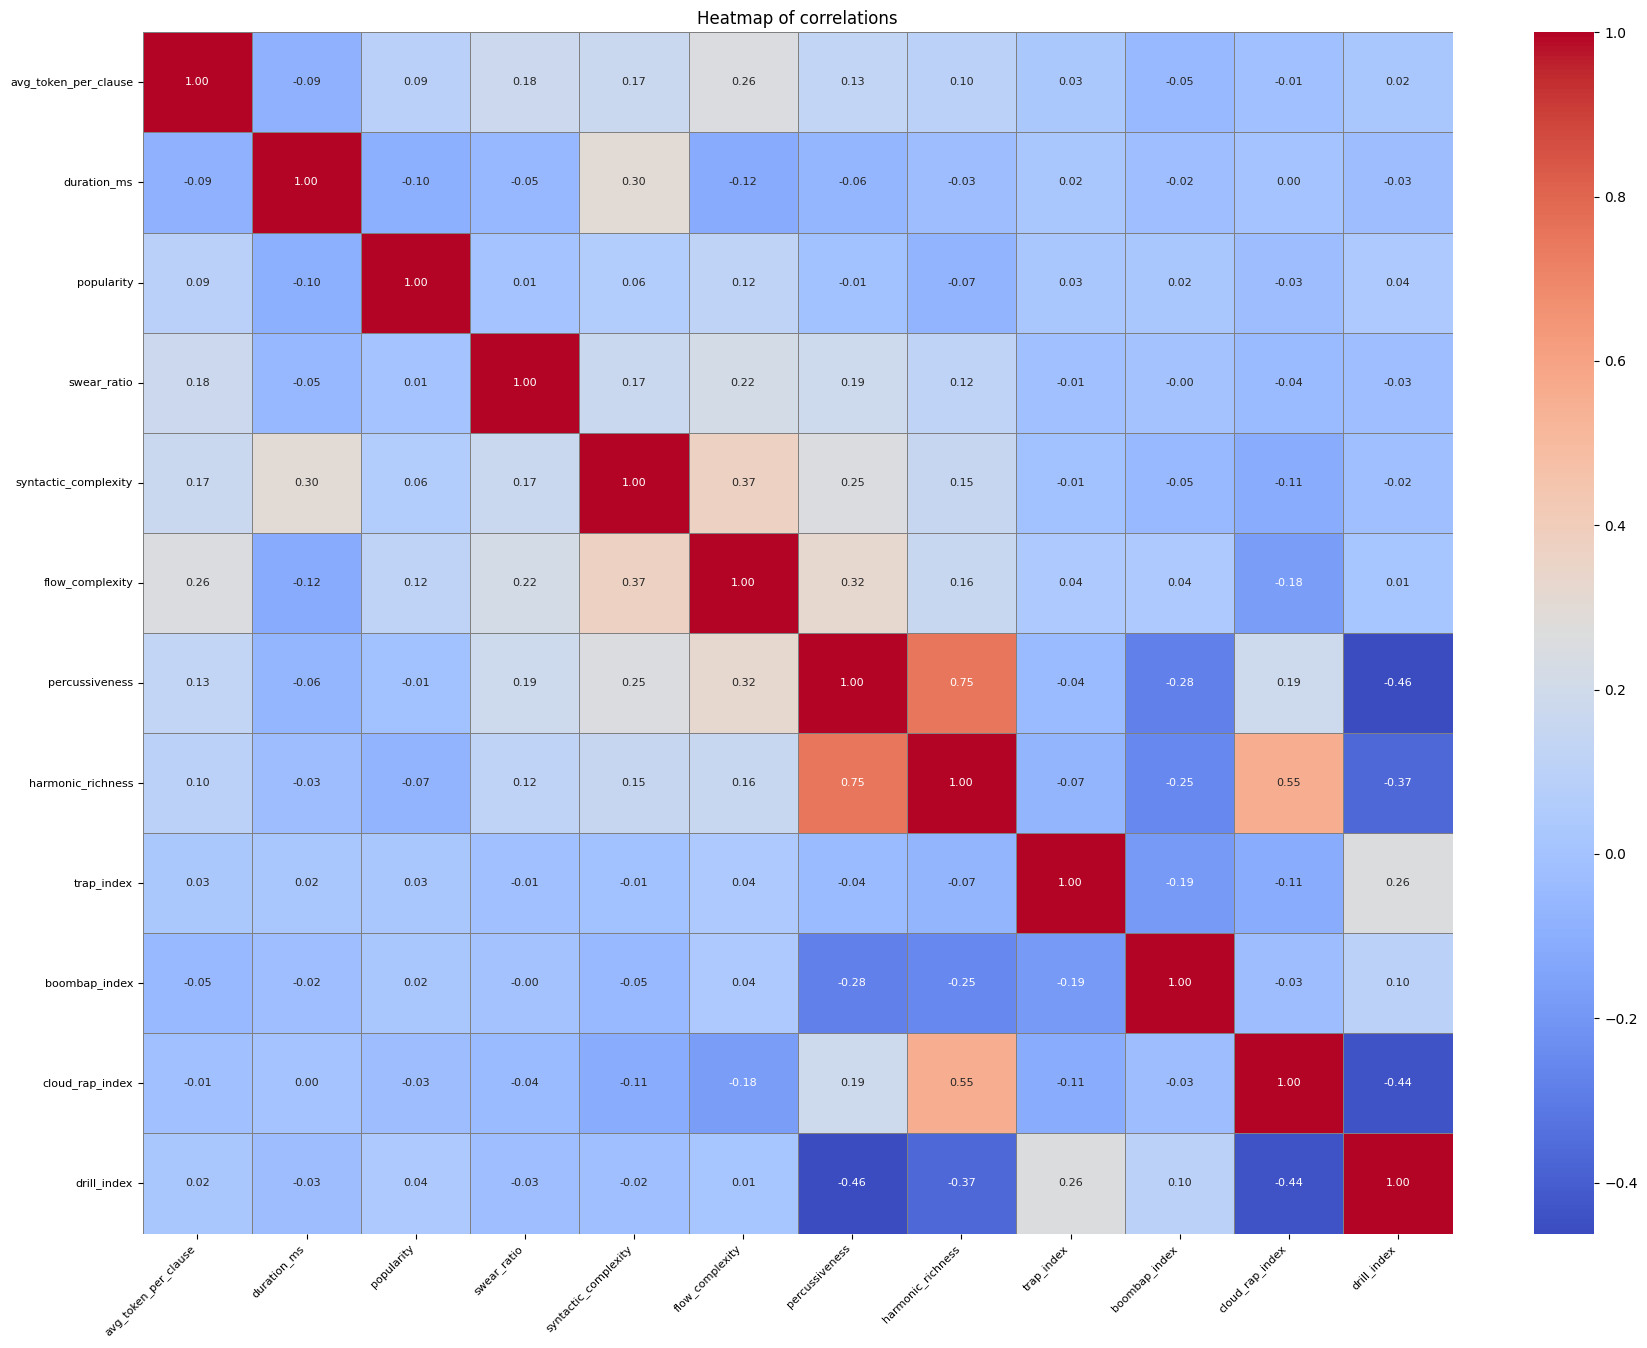

In [78]:
full_heatmap(df_cleaned)

In [79]:
df_cleaned.to_csv('../../clustering_dataset/merged_dataset_clean.csv', index=False)